# TP 1 — Complexité algorithmique : mesurer, comparer, extrapoler

**R3.02 — Développement Efficace**

Dans le cours, vous avez appris à *majorer* le nombre d'opérations d'un algorithme avec les
notations $O$ et $o$. Ce TP fait le chemin inverse : on part de deux programmes qui résolvent
**exactement le même problème**, on les chronomètre, et on retrouve leur classe de complexité
dans les mesures.

À la fin, vous devriez être capables de répondre à cette question sans lancer le calcul :

> *« Mon programme met 8 secondes sur 16 000 données. Combien mettra-t-il sur un million ? »*

La réponse dépend uniquement de la classe de complexité — et l'écart entre les deux réponses
possibles se compte ici en **heures contre secondes**.

---
## Le problème

Un serveur enregistre les connexions de ses utilisateurs. Chaque connexion est un couple
d'entiers `(début, fin)` : l'utilisateur est connecté à partir de l'instant `début`, et
déconnecté à partir de l'instant `fin`. Autrement dit, la connexion occupe l'intervalle
**semi-ouvert** $[\,début,\ fin\,)$.

**Question :** quel a été le **nombre maximal de connexions simultanées** ?

C'est le dimensionnement du serveur : ce nombre, c'est le nombre de connexions qu'il faut
pouvoir encaisser en pointe.

### Un exemple à la main

```
connexions = [(0, 5), (2, 8), (4, 6), (7, 9)]

instant :   0    1    2    3    4    5    6    7    8    9
(0,5)    :  #########################
(2,8)    :            ##############################
(4,6)    :                      ##########
(7,9)    :                                     ##########
actives  :  1    1    2    2    3    2    1    2    1    0
```

Le pic vaut **3**, atteint sur l'intervalle $[4, 5)$.

Notez qu'à l'instant 5, la connexion `(0,5)` est **déjà terminée**.
Ce détail aura son importance.

In [1]:
import random
import time
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

---
## Partie 1 — Fabriquer des instances

Pour mesurer, il faut des données. On tire `n` connexions au hasard sur un horizon de temps
proportionnel à `n`, de sorte que la **densité** de connexions reste comparable quelle que
soit la taille : sans cela, on mesurerait un effet de densité en plus de l'effet de taille.

In [2]:
def genere_connexions(n, duree_max=100, graine=None):
    """Renvoie n connexions (debut, fin) tirees au hasard.

    L'horizon de temps vaut 10*n, ce qui maintient une densite de
    connexions constante quand n grandit.

    Args:
        n (int): nombre de connexions
        duree_max (int): duree maximale d'une connexion
        graine (int): graine aleatoire, pour rendre les mesures reproductibles

    Returns:
        list: liste de couples (debut, fin) avec debut < fin
    """
    if graine is not None:
        random.seed(graine)
    horizon = 10 * n
    connexions = []
    for _ in range(n):
        debut = random.randint(0, horizon)
        fin = debut + random.randint(1, duree_max)
        connexions.append((debut, fin))
    return connexions

In [3]:
exemple = genere_connexions(8, duree_max=20, graine=42)
exemple

[(14, 15), (35, 43), (28, 33), (13, 31), (11, 30), (54, 56), (3, 6), (27, 35)]

---
## Partie 2 — L'approche naïve

### L'idée

Le nombre de connexions actives ne change qu'aux instants où une connexion **commence** ou
**se termine**. Entre deux tels instants, il est constant. Le maximum est donc forcément
atteint **juste après un début de connexion**.

Il suffit donc, pour chaque connexion, de se placer à son instant de début et de compter
combien de connexions sont actives à cet instant — puis de garder le plus grand de ces comptes.

In [4]:
def pic_naif(connexions):
    """Renvoie le nombre maximal de connexions simultanees.

    Pour chaque debut de connexion, compte les connexions actives a cet instant.

    Args:
        connexions (list): liste de couples (debut, fin)

    Returns:
        int: le nombre maximal de connexions simultanees
    """
    pic = 0
    for (debut, _) in connexions:
        simultanees = 0
        for (d, f) in connexions:
            if d <= debut < f:
                simultanees += 1
        if simultanees > pic:
            pic = simultanees
    return pic

In [5]:
pic_naif([(0, 5), (2, 8), (4, 6), (7, 9)])   # doit valoir 3

3

### Sa complexité

Deux boucles imbriquées sur les $n$ connexions, et un test à coût constant à l'intérieur.
Le nombre d'opérations est donc de l'ordre de $n \times n$ :

$$
f(n) = n^2 \in O(n^2)
$$

C'est un coût **quadratique**. Retenez le chiffre suivant, on va le vérifier expérimentalement :
si le temps est proportionnel à $n^2$, alors **doubler $n$ multiplie le temps par 4**.

---
## Partie 3 — L'approche par balayage

### L'idée

Plutôt que de recompter tout depuis zéro à chaque instant, on va parcourir le temps **une
seule fois**, du début à la fin, en tenant à jour un compteur.

On fabrique la liste des **événements** : chaque connexion `(début, fin)` en produit deux,
un `+1` à l'instant `début` et un `-1` à l'instant `fin`. On **trie** ces $2n$ événements par
instant, puis on les parcourt en accumulant les `±1`. Le compteur donne à tout moment le
nombre de connexions actives ; on retient son maximum.

C'est ce qu'on appelle un **balayage** (*sweep line*).

### Le piège des ex æquo

Que faire quand une connexion se termine exactement à l'instant où une autre commence ?
Comme les intervalles sont semi-ouverts, elles ne sont **pas** simultanées : il faut traiter
le `-1` **avant** le `+1`.

Bonne nouvelle : Python trie les couples par ordre lexicographique, et $-1 < +1$. En codant
les événements sous la forme `(instant, delta)`, un simple `.sort()` place spontanément les
fins avant les débuts à instant égal. **C'est exactement le comportement voulu**, mais il
faut le savoir — c'est le genre de détail qui fait qu'un algorithme « presque juste » donne
un résultat faux sur certaines instances.

In [6]:
def pic_balayage(connexions):
    """Renvoie le nombre maximal de connexions simultanees, par balayage.

    Fabrique 2n evenements (+1 au debut, -1 a la fin), les trie,
    puis les parcourt en maintenant un compteur.

    Args:
        connexions (list): liste de couples (debut, fin)

    Returns:
        int: le nombre maximal de connexions simultanees
    """
    evenements = []
    for (debut, fin) in connexions:
        evenements.append((debut, +1))
        evenements.append((fin, -1))

    # print(evenements) # pour comprendre le fonctionnement de l'algorithme
    evenements.sort()          # O(n log n)
    # print(evenements) # pour comprendre le fonctionnement de l'algorithme

    courant = 0
    pic = 0
    for (_, delta) in evenements:
        courant += delta
        if courant > pic:
            pic = courant
    return pic

In [7]:
pic_balayage([(0, 5), (2, 8), (4, 6), (7, 9)])   # doit valoir 3 aussi

3

### Sa complexité

Le calcul se décompose en trois morceaux :

| étape | coût |
|---|---|
| fabriquer les $2n$ événements | $O(n)$ |
| **les trier** | $O(n \log n)$ (complexité optimale du tri, implémenté par la fonction `sort`)|
| les parcourir en comptant | $O(n)$ |

Le total est dominé par le tri :

$$
f(n) = n + n\log n + n \in O(n \log n)
$$

> **Remarque.** On admet ici que le `.sort()` de Python est en $O(n\log n)$. Ce n'est pas
> un acte de foi gratuit : c'est précisément ce qu'on démontrera dans le chapitre sur les
> tris. Pour l'instant, retenez que **trier coûte $n \log n$**, et que c'est presque aussi
> bon marché que parcourir.

Et le chiffre à vérifier : si le temps est proportionnel à $n\log n$, alors doubler $n$
multiplie le temps par $2\,\frac{\log(2n)}{\log n}$, c'est-à-dire **un peu plus que 2** — et
d'autant plus proche de 2 que $n$ est grand.

---
## Partie 4 — Vérifier avant de mesurer

Un algorithme rapide mais faux n'a aucun intérêt. Avant de chronométrer quoi que ce soit,
on s'assure que les deux fonctions donnent **le même résultat**.

C'est le grand avantage d'avoir deux implémentations : la version naïve, lente mais
manifestement correcte, sert d'**oracle** pour valider la version maligne. Cette technique
porte un nom — le *test différentiel* — et c'est l'une des façons les plus efficaces de
tester du code.

In [8]:
random.seed(0)
desaccords = 0

for essai in range(300):
    n = random.randint(0, 60)
    c = genere_connexions(n, duree_max=random.randint(1, 30))
    if pic_naif(c) != pic_balayage(c):
        desaccords += 1
        print("DÉSACCORD sur", c)

print(f"300 instances aléatoires testées, {desaccords} désaccord(s).")

300 instances aléatoires testées, 0 désaccord(s).


In [9]:
# Les cas limites, ceux qui cassent les implementations approximatives
cas = {
    "liste vide"                    : [],
    "une seule connexion"           : [(3, 7)],
    "intervalles jointifs [0,5) [5,10)" : [(0, 5), (5, 10)],
    "trois connexions identiques"   : [(0, 5), (0, 5), (0, 5)],
    "une englobe toutes les autres" : [(0, 100), (10, 20), (30, 40)],
}

for nom, c in cas.items():
    print(f"{nom:<36} naïf={pic_naif(c)}   balayage={pic_balayage(c)}")

liste vide                           naïf=0   balayage=0
une seule connexion                  naïf=1   balayage=1
intervalles jointifs [0,5) [5,10)    naïf=1   balayage=1
trois connexions identiques          naïf=3   balayage=3
une englobe toutes les autres        naïf=2   balayage=2


> **À noter.** Le cas `[(0,5), (5,10)]` vaut **1**, pas 2 : la première connexion est
> terminée quand la seconde commence. Si votre balayage renvoie 2 ici, c'est que l'ordre
> des ex æquo est mauvais.

---
## Partie 5 — Chronométrer

On utilise `time.perf_counter()`, l'horloge la plus précise que fournit Python pour mesurer
des durées.

Une mesure unique est bruitée (le système d'exploitation fait autre chose en même temps).
On répète donc chaque mesure et on garde le **minimum** : les perturbations extérieures ne
peuvent que ralentir le programme, jamais l'accélérer, donc le minimum est l'estimation la
plus fidèle du coût réel.

In [10]:
def chronometre(fonction, donnees, repetitions=3):
    """Mesure le temps d'execution de fonction(donnees), en secondes.

    Repete la mesure et renvoie le minimum, pour limiter le bruit.

    Args:
        fonction (callable): la fonction a chronometrer
        donnees: son argument
        repetitions (int): nombre de mesures

    Returns:
        float: le temps minimal observe, en secondes
    """
    meilleur = float("inf")
    for _ in range(repetitions):
        depart = time.perf_counter()
        fonction(donnees)
        duree = time.perf_counter() - depart
        if duree < meilleur:
            meilleur = duree
    return meilleur

In [11]:
tailles_naif = [250, 500, 1000, 2000, 4000, 8000, 16000]
temps_naif = []

for n in tailles_naif:
    c = genere_connexions(n, graine=1)
    t = chronometre(pic_naif, c, repetitions=3)
    temps_naif.append(t)
    print(f"n = {n:>6}   t = {t:8.4f} s")

n =    250   t =   0.0027 s
n =    500   t =   0.0084 s
n =   1000   t =   0.0317 s
n =   2000   t =   0.1200 s
n =   4000   t =   0.4808 s
n =   8000   t =   1.9207 s
n =  16000   t =   7.8988 s


On s'arrête à $n = 16\,000$ : au-delà, l'approche naïve devient trop lente pour une séance
de TP. Retenez ce fait, il est au cœur du sujet — **ce n'est pas une limite de la machine,
c'est une limite de l'algorithme.**

Chronométrons maintenant le balayage sur **exactement les mêmes tailles**, pour que la
comparaison soit honnête.

In [12]:
# D'abord sur EXACTEMENT les memes tailles que le naif, pour pouvoir comparer
temps_bal_petit = []
for n in tailles_naif:
    c = genere_connexions(n, graine=1)
    temps_bal_petit.append(chronometre(pic_balayage, c, repetitions=5))

print("Sur les mêmes tailles que le naïf :")
print(f"{'n':>7} {'naïf (s)':>12} {'balayage (s)':>14} {'rapport':>10}")
for i, n in enumerate(tailles_naif):
    r = temps_naif[i] / temps_bal_petit[i]
    print(f"{n:>7} {temps_naif[i]:>12.4f} {temps_bal_petit[i]:>14.5f} {r:>9.0f}x")

Sur les mêmes tailles que le naïf :
      n     naïf (s)   balayage (s)    rapport
    250       0.0027        0.00008        32x
    500       0.0084        0.00018        48x
   1000       0.0317        0.00039        82x
   2000       0.1200        0.00099       121x
   4000       0.4808        0.00202       238x
   8000       1.9207        0.00436       440x
  16000       7.8988        0.00970       814x


Le rapport se creuse : il n'est pas constant, il **grandit avec $n$**. C'est la signature
d'une différence de classe de complexité, et non d'un simple facteur constant. Deux
algorithmes de même classe garderaient un rapport stable.

Le balayage étant si rapide, poussons-le beaucoup plus loin — jusqu'au million de connexions,
en doublant la taille à chaque étape.

In [13]:
tailles_bal = [31250, 62500, 125000, 250000, 500000, 1000000]
temps_bal = []

for n in tailles_bal:
    c = genere_connexions(n, graine=1)
    t = chronometre(pic_balayage, c, repetitions=3)
    temps_bal.append(t)
    print(f"n = {n:>8}   t = {t:8.4f} s")

n =    31250   t =   0.0197 s
n =    62500   t =   0.0440 s
n =   125000   t =   0.1019 s
n =   250000   t =   0.2355 s
n =   500000   t =   0.5851 s
n =  1000000   t =   1.2772 s


---
## Partie 6 — Les graphiques

### En échelle ordinaire

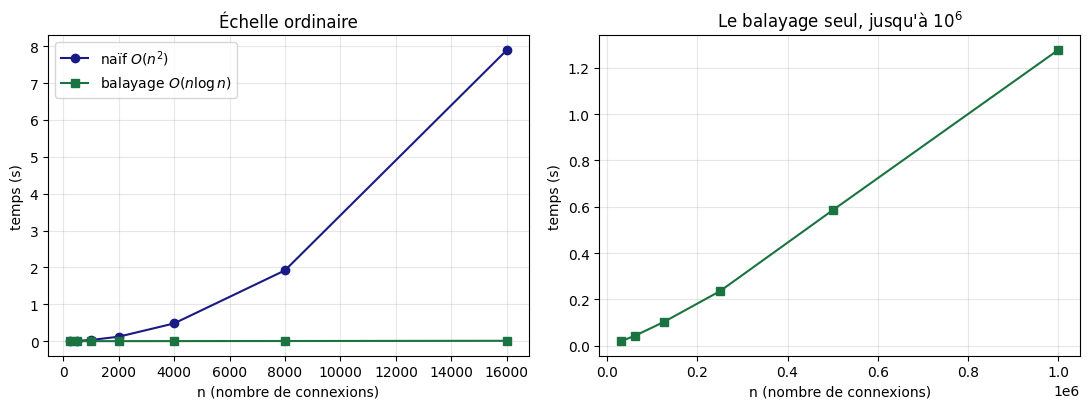

In [14]:
plt.figure(figsize=(11, 4.2))

plt.subplot(1, 2, 1)
plt.plot(tailles_naif, temps_naif, "o-", color="#1a1a85", label="naïf $O(n^2)$")
plt.plot(tailles_naif, temps_bal_petit, "s-", color="#1a7340", label="balayage $O(n\\log n)$")
plt.xlabel("n (nombre de connexions)")
plt.ylabel("temps (s)")
plt.title("Échelle ordinaire")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(tailles_bal, temps_bal, "s-", color="#1a7340")
plt.xlabel("n (nombre de connexions)")
plt.ylabel("temps (s)")
plt.title("Le balayage seul, jusqu'à $10^6$")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Sur le graphique de gauche, la courbe du naïf s'envole tandis que celle du balayage reste
écrasée sur l'axe — au point qu'on ne la distingue plus. C'est le problème des échelles
ordinaires : dès que deux quantités diffèrent d'un facteur mille, l'une des deux devient
invisible.

### En échelle logarithmique

L'échelle log-log règle ce problème, et offre un bonus considérable. Si $t(n) = C \cdot n^k$,
alors

$$
\log t(n) = \log C + k \log n
$$

Autrement dit : **en échelle log-log, une complexité polynomiale devient une droite, et
l'exposant est la pente.** On lit la classe de complexité à la règle.

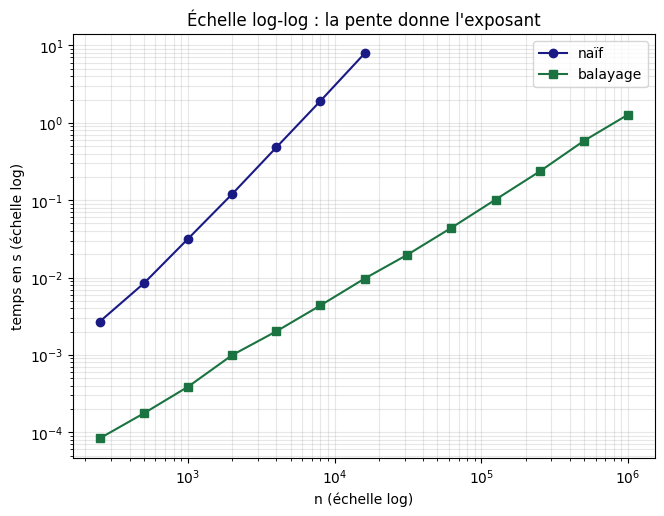

pente mesurée, naïf     : 1.934   (attendu : 2   -> quadratique)
pente mesurée, balayage : 1.215   (attendu : ~1  -> quasi-linéaire)


In [15]:
plt.figure(figsize=(7.5, 5.5))

plt.loglog(tailles_naif, temps_naif, "o-", color="#1a1a85", label="naïf")
# le balayage sur TOUTE la plage mesuree, pour couvrir la meme zone que le naif
tailles_bal_tout = tailles_naif + tailles_bal
temps_bal_tout = temps_bal_petit + temps_bal
plt.loglog(tailles_bal_tout, temps_bal_tout, "s-", color="#1a7340", label="balayage")

# pentes mesurees par regression lineaire sur les logarithmes
# (pour le balayage, on n'ajuste que sur les grandes tailles : les petites
#  durent quelques dizaines de microsecondes et sont noyees dans le bruit)
pente_naif = np.polyfit(np.log(tailles_naif), np.log(temps_naif), 1)[0]
pente_bal = np.polyfit(np.log(tailles_bal), np.log(temps_bal), 1)[0]

plt.xlabel("n (échelle log)")
plt.ylabel("temps en s (échelle log)")
plt.title("Échelle log-log : la pente donne l'exposant")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

print(f"pente mesurée, naïf     : {pente_naif:.3f}   (attendu : 2   -> quadratique)")
print(f"pente mesurée, balayage : {pente_bal:.3f}   (attendu : ~1  -> quasi-linéaire)")

La pente du naïf tombe sur 2,00 : l'algorithme est bien quadratique, et les deux droites
n'ont visiblement pas la même inclinaison sur la zone où elles se superposent.

La pente du balayage vaut environ **1,2**. La théorie en prédit plutôt 1,08 sur cette plage :
un $O(n\log n)$ est une droite de pente 1 très légèrement incurvée vers le haut, le facteur
$\log n$ croissant lentement. L'écart entre 1,08 et 1,2 n'est pas une erreur de votre part —
c'est ce que coûte, en pratique, la fabrication des $2n$ couples et leur rangement en mémoire,
choses que l'analyse asymptotique néglige délibérément.

**Il faut s'attendre à cet écart.** Une mesure ne retrouve jamais l'exposant théorique à la
troisième décimale, et un TP qui prétendrait le contraire vous mentirait. Ce qu'il faut lire
dans ces deux nombres, c'est qu'ils valent **2,0 et 1,2** — pas 2,0 et 2,0. La question n'est
jamais « la pente vaut-elle exactement $k$ ? », mais « de quelle classe de complexité
s'agit-il ? ».

---
## Partie 8 — Conclusion

Voilà ce qu'il faut retenir de ce TP.

Les deux programmes sont écrits dans le **même langage**, tournent sur la **même machine**,
et résolvent le **même problème** — nous avons vérifié qu'ils donnent toujours la même
réponse. Ils ne diffèrent que par la méthode. Et pourtant, sur un jeu de données d'un
million de connexions, l'un répond avant que vous ayez fini de lire cette phrase, tandis que
l'autre tourne encore le lendemain matin.

Aucune optimisation de code, aucun processeur plus rapide, aucun langage compilé ne rattrape
cet écart : passer à un langage 50 fois plus rapide ferait tomber les heures à quelques
minutes, là où le changement d'algorithme les fait tomber à **une seconde**. C'est la
différence entre $O(n^2)$ et $O(n \log n)$.

> **La constante ne sauve personne.** Dans la définition $f(n) \leq C \cdot g(n)$, la
> constante $C$ résume tout ce qui dépend de la machine et du langage. Le test du doublement
> l'a fait disparaître, et l'extrapolation ci-dessus n'en dépend pas non plus. Ce qui
> décide, c'est $g$.